In [50]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Loading the Dataset

The Online Retail dataset is loaded using Pandas. This dataset contains customer transactions and product purchase information used for market basket analysis.

In [51]:
df = pd.read_excel("/content/Online retail.xlsx", header=None)

df.head()

,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


# Data Preprocessing

Data preprocessing is performed to improve data quality before applying Association Rule Mining.

The following preprocessing steps are performed:
- Removed missing values
- Removed duplicate records
- Selected only important columns
- Converted transactions into basket format

# Transaction Formation

Products purchased in the same invoice are grouped together to form transactions. Each transaction represents a customer basket.

In [52]:
transactions = []

for i in range(len(df)):

    transaction = str(df.iloc[i,0]).split(',')

    transactions.append(transaction)

transactions[:5]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [53]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,bramble,brownies,bug spray,burger sauce,burgers,butter,cake,candy bars,carrots,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,clothes accessories,cookies,cooking oil,corn,cottage cheese,cream,dessert wine,eggplant,eggs,energy bar,energy drink,...,oil,olive oil,pancakes,parmesan cheese,pasta,pepper,pet food,pickles,protein bar,red wine,rice,salad,salmon,salt,sandwich,shallot,shampoo,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,tomato juice,tomato sauce,tomatoes,toothpaste,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [54]:
df.shape

(7501, 1)

In [55]:
df.describe()

,0
count,7501
unique,5176
top,cookies
freq,223


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
dtypes: object(1)
memory usage: 58.7+ KB


In [57]:
df.columns

Index([0], dtype='int64')

In [58]:
df.isnull().sum()

,0
0,0


In [59]:
df.duplicated().sum()

np.int64(2325)

In [60]:
df.drop_duplicates(inplace=True)

# Apriori Algorithm

The Apriori algorithm is used to identify frequent itemsets from transaction data.

The algorithm finds product combinations that occur frequently together based on minimum support threshold.

In [61]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_items.head()

,support,itemsets
0,0.020397,(almonds)
1,0.033329,(avocado)
2,0.010799,(barbecue sauce)
3,0.014265,(black tea)
4,0.011465,(body spray)


# Rule Analysis

The generated rules are analysed using Lift values.

Higher lift values indicate stronger relationships between products and provide useful business insights for recommendation systems and product placement strategies.

In [62]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(avocado),(mineral water),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,(mineral water),(avocado),0.238368,0.033329,0.011598,0.048658,1.459926,1.0,0.003654,1.016113,0.413630,0.044593,0.015857,0.198329
2,(burgers),(cake),0.087188,0.081056,0.011465,0.131498,1.622319,1.0,0.004398,1.058080,0.420238,0.073129,0.054892,0.136473
3,(cake),(burgers),0.081056,0.087188,0.011465,0.141447,1.622319,1.0,0.004398,1.063198,0.417434,0.073129,0.059442,0.136473
4,(chocolate),(burgers),0.163845,0.087188,0.017064,0.104150,1.194537,1.0,0.002779,1.018933,0.194767,0.072934,0.018581,0.149934


In [63]:
rules = rules.sort_values(by='lift', ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
214,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
215,(ground beef),(herb & pepper),0.098254,0.049460,0.015998,0.162822,3.291994,1.0,0.011138,1.135410,0.772094,0.121457,0.119261,0.243136
386,(ground beef),"(mineral water, spaghetti)",0.098254,0.059725,0.017064,0.173677,2.907928,1.0,0.011196,1.137902,0.727602,0.121097,0.121190,0.229696
383,"(mineral water, spaghetti)",(ground beef),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
398,(olive oil),"(mineral water, spaghetti)",0.065858,0.059725,0.010265,0.155870,2.609786,1.0,0.006332,1.113898,0.660314,0.089017,0.102252,0.163873
395,"(mineral water, spaghetti)",(olive oil),0.059725,0.065858,0.010265,0.171875,2.609786,1.0,0.006332,1.128021,0.656007,0.089017,0.113491,0.163873
193,(tomatoes),(frozen vegetables),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
192,(frozen vegetables),(tomatoes),0.095321,0.068391,0.016131,0.169231,2.474464,1.0,0.009612,1.121381,0.658656,0.109304,0.108243,0.202549
188,(shrimp),(frozen vegetables),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
189,(frozen vegetables),(shrimp),0.095321,0.071457,0.016664,0.174825,2.446574,1.0,0.009853,1.125268,0.653563,0.111012,0.111323,0.204017


In [64]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head(10)

,antecedents,consequents,support,confidence,lift
214,(herb & pepper),(ground beef),0.015998,0.323450,3.291994
215,(ground beef),(herb & pepper),0.015998,0.162822,3.291994
386,(ground beef),"(mineral water, spaghetti)",0.017064,0.173677,2.907928
383,"(mineral water, spaghetti)",(ground beef),0.017064,0.285714,2.907928
398,(olive oil),"(mineral water, spaghetti)",0.010265,0.155870,2.609786
395,"(mineral water, spaghetti)",(olive oil),0.010265,0.171875,2.609786
193,(tomatoes),(frozen vegetables),0.016131,0.235867,2.474464
192,(frozen vegetables),(tomatoes),0.016131,0.169231,2.474464
188,(shrimp),(frozen vegetables),0.016664,0.233209,2.446574
189,(frozen vegetables),(shrimp),0.016664,0.174825,2.446574


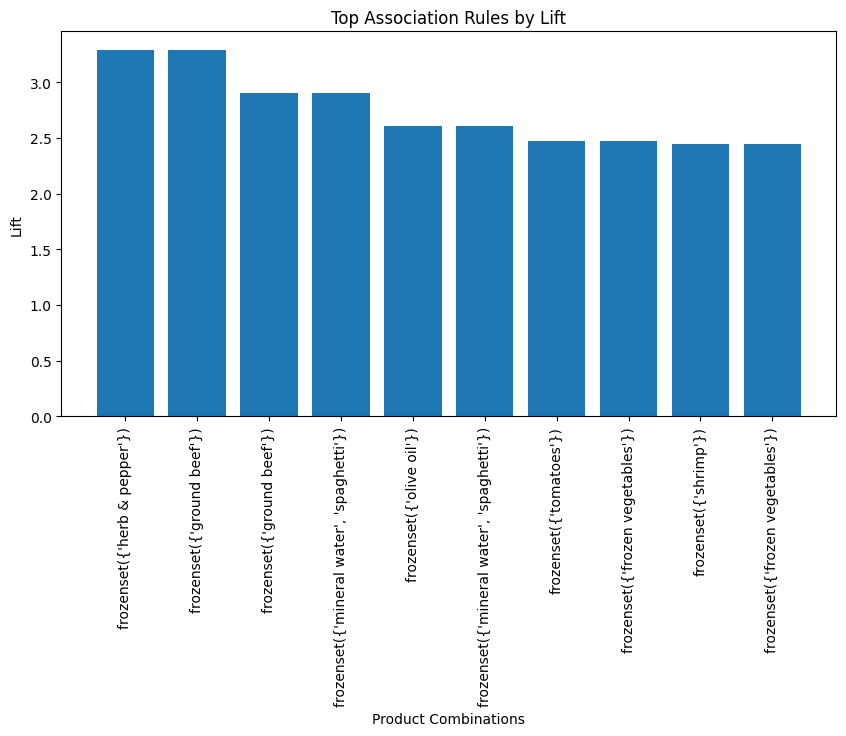

In [65]:
import matplotlib.pyplot as plt

top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(range(len(top_rules)), top_rules['lift'])

plt.xticks(range(len(top_rules)),
           [str(i) for i in top_rules['antecedents']],
           rotation=90)

plt.title("Top Association Rules by Lift")

plt.xlabel("Product Combinations")

plt.ylabel("Lift")

plt.show()

# Insights from Association Rules

- Customers tend to purchase certain products together frequently.
- High lift values indicate strong product associations.
- Association rules can help businesses improve:
  - Product recommendations
  - Cross-selling strategies
  - Store layouts
  - Inventory management

# Interview Questions and Answers on Association Rules

---

# 1. What is Association Rule Mining?

Association Rule Mining is a data mining technique used to discover relationships and patterns between items in large datasets.

It is mainly used in:
- Market Basket Analysis
- Recommendation Systems
- Customer Behavior Analysis

Example:
If customers buy bread, they may also buy butter.

---

# 2. What is Market Basket Analysis?

Market Basket Analysis identifies products that are frequently purchased together by customers.

It helps businesses:
- Improve product placement
- Increase cross-selling
- Build recommendation systems

---

# 3. What is the Apriori Algorithm?

Apriori is a frequent itemset mining algorithm used to discover association rules.

It works on the principle:

"If an itemset is frequent, all of its subsets must also be frequent."

---

# 4. What is Support in Association Rules?

Support measures how frequently an itemset appears in the dataset.

Formula:

Support(A) =
(Number of transactions containing A) /
(Total number of transactions)

Higher support means the item appears more frequently.

---

# 5. What is Confidence?

Confidence measures how often item B is purchased when item A is purchased.

Formula:

Confidence(A → B) =
Support(A and B) / Support(A)

Higher confidence indicates stronger association.

---

# 6. What is Lift and why is it important?

Lift measures how strongly two items are associated compared to random chance.

Formula:

Lift(A → B) =
Confidence(A → B) / Support(B)

Interpretation:
- Lift > 1 → Positive association
- Lift = 1 → No association
- Lift < 1 → Negative association

Lift is important because it shows the strength of relationships.

---

# 7. What are Frequent Itemsets?

Frequent itemsets are groups of items that appear together frequently in transactions.

Example:
{Milk, Bread}

if purchased together many times.

---

# 8. Why is preprocessing important in Association Rules?

Preprocessing improves data quality and model accuracy.

It includes:
- Handling missing values
- Removing duplicates
- Formatting transactions properly

---

# 9. What is TransactionEncoder?

TransactionEncoder converts transaction data into binary matrix format.

Example:

| Milk | Bread | Butter |
|------|--------|---------|
| True | True   | False   |

This format is required for Apriori.

---

# 10. What is the purpose of one-hot encoding in Apriori?

One-hot encoding converts categorical transaction data into binary values:
- 1 → Product purchased
- 0 → Product not purchased

This helps the algorithm process the data efficiently.

---

# 11. What is antecedent and consequent?

In a rule:

A → B

- A is called antecedent
- B is called consequent

Meaning:
If A is purchased, B is likely to be purchased.

---

# 12. What are the applications of Association Rule Mining?

Applications include:
- Product recommendation
- Cross-selling
- Fraud detection
- Medical diagnosis
- Website usage analysis

---

# 13. What are the limitations of Association Rule Mining?

Limitations:
- Generates too many rules
- Computationally expensive
- Difficult to choose thresholds
- Some rules may be meaningless

---

# 14. What is minimum support threshold?

Minimum support threshold defines the minimum frequency required for an itemset to be considered frequent.

It helps reduce unnecessary rules.

---

# 15. What happens if support is set too high?

If support is too high:
- Important patterns may be missed
- Fewer rules are generated

---

# 16. What happens if support is set too low?

If support is too low:
- Too many rules are generated
- Computational complexity increases

---

# 17. Why is lift better than confidence sometimes?

Confidence can be misleading when items are very common.

Lift considers the actual probability of occurrence and provides better insight into true relationships.

---

# 18. What libraries are commonly used for Association Rules in Python?

Common libraries:
- Pandas
- Mlxtend
- NumPy
- Matplotlib

---

# 19. What is the difference between supervised and unsupervised learning?

Supervised Learning:
- Uses labeled data

Unsupervised Learning:
- Uses unlabeled data

Association Rule Mining is an unsupervised learning technique.

---

# 20. How does Association Rule Mining help businesses?

It helps businesses:
- Understand customer purchasing behavior
- Improve recommendations
- Increase sales
- Optimize inventory management